# Exploratory Data Analysis

## Business Objective

The purpose of this notebook is to explore the datasets and identify business insights related to customer behavior, sales performance, product demand and operational efficiency.

Each analysis addresses a specific business question and concludes with practical recommendations.

# Business Question 1

## How has the number of orders changed over time?

Understanding sales dynamics is essential for identifying business growth, seasonality and unusual fluctuations in demand.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from IPython.display import display

In [2]:
DATA_PATH = Path("../06_Datasets/raw")

dataset_files = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "categories": "product_category_name_translation.csv"
}

datasets = {}
for name, filename in dataset_files.items():
    datasets[name] = pd.read_csv(DATA_PATH / filename)

In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

datasets["orders"][date_columns] = (
    datasets["orders"][date_columns]
    .apply(pd.to_datetime)
)

In [6]:
orders = datasets["orders"].copy()
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02


In [7]:
orders_by_month = (
    orders
    .groupby("purchase_month")
    .size()
    .reset_index(name="orders")
)
orders_by_month

,purchase_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [8]:
orders_by_month["purchase_month"] = (
    orders_by_month["purchase_month"]
    .dt.to_timestamp()
)

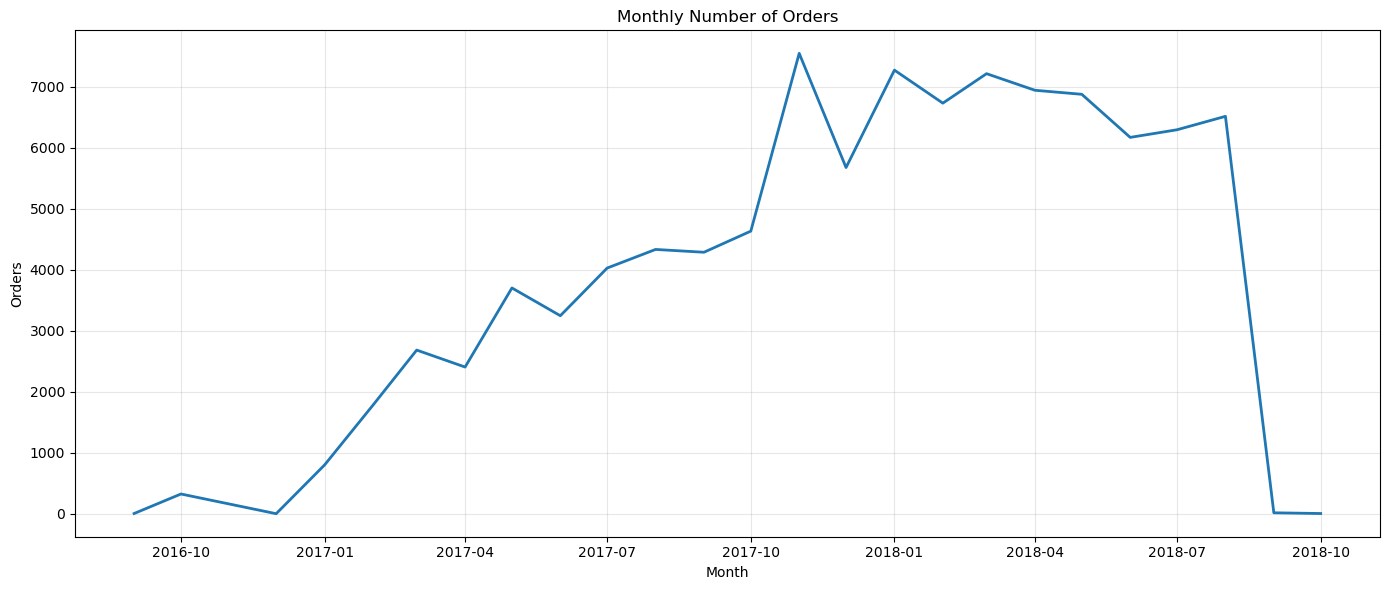

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(
    orders_by_month["purchase_month"],
    orders_by_month["orders"],
    linewidth=2
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Findings

### Observation

-

### Possible Explanation

-

### Business Impact

-

### Recommendation

-

In [10]:
print(orders["order_purchase_timestamp"].min())
print(orders["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


In [11]:
orders[
    orders["order_purchase_timestamp"] < "2016-10-01"
].sort_values("order_purchase_timestamp")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20,2016-09
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,NaT,NaT,2016-10-28,2016-09
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,NaT,NaT,2016-09-30,2016-09
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,2016-09


In [12]:
orders[
    orders["order_purchase_timestamp"] >= "2018-09-01"
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17,2018-09
5149,ea844c92cf978ea23321fa7fe5871761,6ddc45ad08e6a2c885ca2255fc52d6df,canceled,2018-09-13 09:56:12,NaT,NaT,NaT,2018-09-27,2018-09
9976,87ae60ef8b08ae0e5f903cacb53a6904,fea4d57ed3a45455f89c25ef3dae8ee8,canceled,2018-09-11 16:45:54,NaT,NaT,NaT,2018-09-26,2018-09
16366,bd35b677fd239386e9861d11ae98ab56,ad2eb5d02c0808bcd8743117f6383cf6,canceled,2018-09-17 17:21:16,NaT,NaT,NaT,2018-10-01,2018-09
20778,4d59cc2a2e7bb6c0a851725f5888a9b5,ead83a4f8f7be8c3034b2e98754a6147,canceled,2018-09-06 14:50:07,NaT,NaT,NaT,2018-09-21,2018-09
24410,0d3adebce4bebc1f80a7f36e9833f497,a7c87c25dbdded68c26c640582cb5ddb,canceled,2018-09-03 18:40:50,NaT,NaT,NaT,2018-10-02,2018-09
31170,21a00b08cbeb5716bbb66105e3dbd850,002b5342c72978cf0aba6aae1f5d5293,canceled,2018-09-10 17:51:25,NaT,NaT,NaT,2018-09-20,2018-09
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03 18:55:29,NaT,NaT,NaT,2018-10-16,2018-10
33979,5aac76cf7b07dd06fa4d50bf461d2f40,7a8a02e54cf3472df427e927f8b9c046,canceled,2018-09-25 11:59:18,NaT,NaT,NaT,2018-10-11,2018-09
37003,869997fbe01f39d184956b5c6bccfdbe,55c9dad94ec1a2ba57998bdb376c230a,canceled,2018-09-26 08:40:15,NaT,NaT,NaT,2018-10-25,2018-09


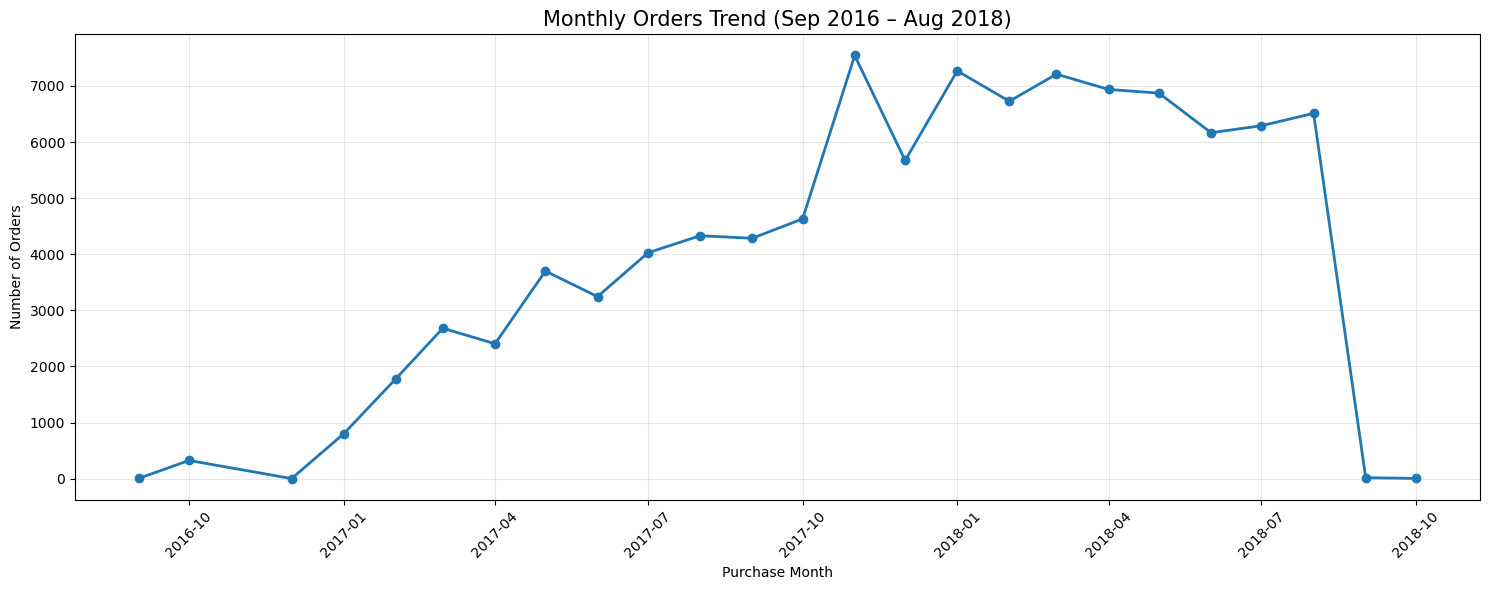

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    orders_by_month["purchase_month"],
    orders_by_month["orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Orders Trend (Sep 2016 – Aug 2018)", fontsize=15)
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
orders_by_month["orders_change"] = (
    orders_by_month["orders"].diff()
)

orders_by_month["growth_rate_%"] = (
    orders_by_month["orders"]
    .pct_change()
    * 100
)
orders_by_month.head(10)

,purchase_month,orders,orders_change,growth_rate_%
0,2016-09-01,4,NaN,NaN
1,2016-10-01,324,320.0,8000.000000
2,2016-12-01,1,-323.0,-99.691358
3,2017-01-01,800,799.0,79900.000000
4,2017-02-01,1780,980.0,122.500000
5,2017-03-01,2682,902.0,50.674157
6,2017-04-01,2404,-278.0,-10.365399
7,2017-05-01,3700,1296.0,53.910150
8,2017-06-01,3245,-455.0,-12.297297
9,2017-07-01,4026,781.0,24.067797


In [29]:
orders_trend = orders_by_month[
    (orders_by_month["purchase_month"] >= "2017-01-01") &
    (orders_by_month["purchase_month"] <= "2018-08-31")
].copy()
orders_trend["orders_change"] = (
    orders_trend["orders"].diff()
)

orders_trend["growth_rate_%"] = (
    orders_trend["orders"]
    .pct_change()
    * 100
)


In [25]:
best_month = orders_trend.loc[
    orders_trend["orders"].idxmax()
]

best_month

purchase_month    2017-11-01 00:00:00
orders                           7544
orders_change                  2913.0
growth_rate_%               62.902181
Name: 13, dtype: object

In [35]:
worst_month = orders_trend.loc[
    orders_trend["orders"].idxmin()
]

worst_month

purchase_month    2017-01-01 00:00:00
orders                            800
orders_change                     NaN
growth_rate_%                     NaN
Name: 3, dtype: object

In [30]:
fastest_growth = orders_trend.loc[
    orders_trend["growth_rate_%"].idxmax()
]

fastest_growth

purchase_month    2017-02-01 00:00:00
orders                           1780
orders_change                   980.0
growth_rate_%                   122.5
Name: 4, dtype: object

In [31]:
largest_drop = orders_trend.loc[
    orders_trend["growth_rate_%"].idxmin()
]

largest_drop

purchase_month    2017-12-01 00:00:00
orders                           5673
orders_change                 -1871.0
growth_rate_%              -24.801166
Name: 14, dtype: object

In [20]:
orders_trend["orders"].describe()

count      20.000000
mean     4954.600000
std      2044.582608
min       800.000000
25%      3586.250000
50%      5152.000000
75%      6764.250000
max      7544.000000
Name: orders, dtype: float64

In [21]:
orders_trend["growth_rate_%"].mean()

np.float64(4009.9788290734054)

In [22]:
orders_trend["orders_change"].mean()

np.float64(325.55)

## Findings

### Observation

The number of monthly orders increased substantially throughout 2017, indicating rapid business expansion.

A pronounced peak was observed in November 2017, followed by a temporary decline in December.

Throughout 2018, monthly order volume remained relatively stable, suggesting that the marketplace entered a more mature growth phase.

### Business Impact

The observed trend indicates successful customer acquisition and marketplace expansion.

The stabilization in 2018 suggests that future business growth may increasingly depend on customer retention and operational improvements rather than rapid expansion.

### Recommendation

Investigate the drivers behind the November 2017 sales peak and evaluate whether similar promotional campaigns can be repeated in future years.

In [36]:
orders_trend["rolling_3m"] = (
    orders_trend["orders"]
    .rolling(3)
    .mean()
)

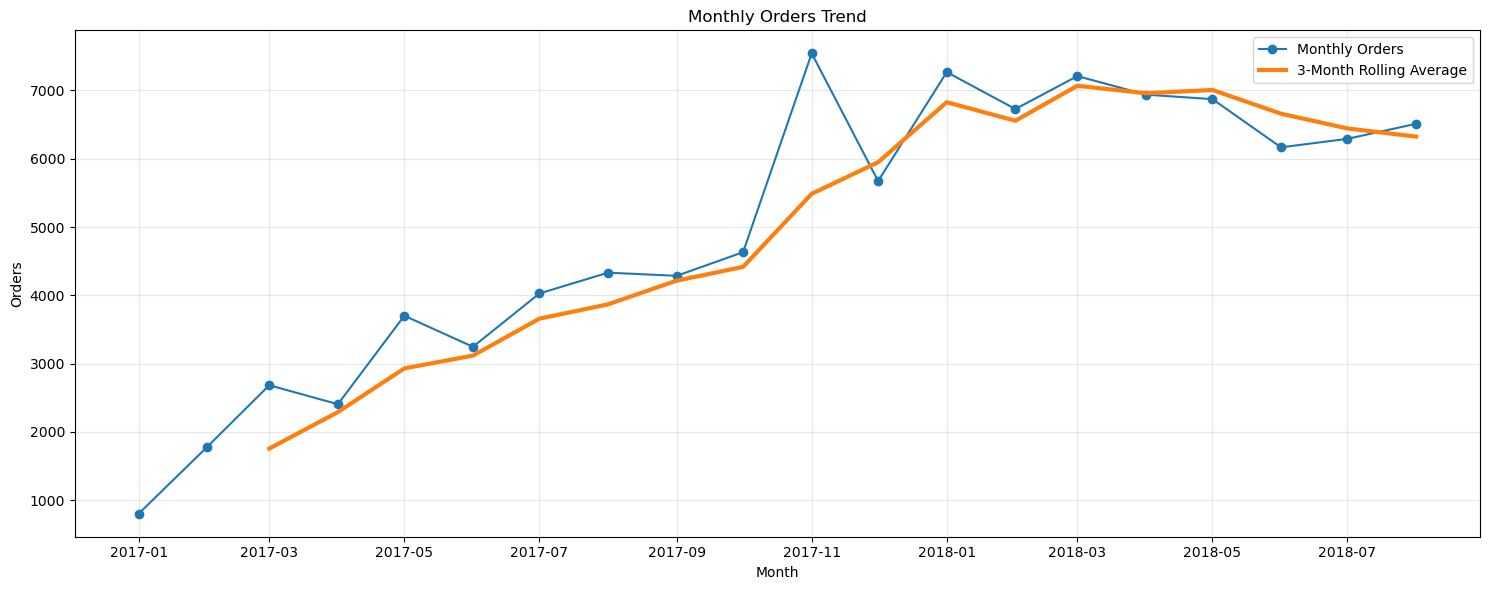

In [37]:
plt.figure(figsize=(15,6))

plt.plot(
    orders_trend["purchase_month"],
    orders_trend["orders"],
    marker="o",
    label="Monthly Orders"
)

plt.plot(
    orders_trend["purchase_month"],
    orders_trend["rolling_3m"],
    linewidth=3,
    label="3-Month Rolling Average"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
summary = pd.DataFrame({
    "Metric": [
        "Highest Sales",
        "Lowest Sales",
        "Fastest Growth",
        "Largest Decline"
    ],
    "Month": [
        best_month["purchase_month"],
        worst_month["purchase_month"],
        fastest_growth["purchase_month"],
        largest_drop["purchase_month"]
    ],
    "Orders": [
        best_month["orders"],
        worst_month["orders"],
        fastest_growth["orders"],
        largest_drop["orders"]
    ],
    "Growth %": [
        best_month["growth_rate_%"],
        worst_month["growth_rate_%"],
        fastest_growth["growth_rate_%"],
        largest_drop["growth_rate_%"]
    ]
})

display(summary)

,Metric,Month,Orders,Growth %
0,Highest Sales,2017-11-01,7544,62.902181
1,Lowest Sales,2017-01-01,800,NaN
2,Fastest Growth,2017-02-01,1780,122.500000
3,Largest Decline,2017-12-01,5673,-24.801166


# Executive Insight

## Key Findings

The analysis of monthly order volume reveals three distinct stages in the marketplace's development.

- **Rapid Growth (January – November 2017):**
  
  The number of monthly orders increased from **800** to **7,544**, representing nearly a **tenfold increase** within eleven months. This indicates successful customer acquisition and rapid marketplace expansion.

- **Peak Performance (November 2017):**

  November 2017 recorded the highest monthly order volume (**7,544 orders**), exceeding the previous month by approximately **63%**. Such a significant increase suggests the influence of major promotional campaigns or seasonal events (e.g., Black Friday).

- **Business Stabilization (2018):**

  Following the November peak, monthly order volume stabilized between approximately **6,200 and 7,300 orders**. This pattern suggests that the marketplace entered a more mature stage where rapid expansion slowed and order volume became relatively consistent.

## Business Interpretation

The marketplace experienced strong expansion during 2017 and successfully reached a stable operating level in 2018.

The transition from rapid growth to stabilization indicates that future business improvements are likely to depend less on acquiring new customers and more on increasing customer retention, improving operational efficiency and maximizing customer lifetime value.

## Recommendations

- Investigate the drivers behind the exceptional performance in November 2017 and assess whether similar campaigns can be replicated.
- Analyze customer retention to determine whether new customers continue making repeat purchases.
- Explore product categories contributing most to business growth.
- Continue monitoring monthly order trends to identify emerging changes in demand.

## KPI Summary

| Metric | Value |
|---------|-------|
| Analysis Period | Jan 2017 – Aug 2018 |
| Total Months | 20 |
| Average Monthly Orders | 4,955 |
| Highest Month | November 2017 (7,544) |
| Lowest Month | January 2017 (800) |
| Largest Monthly Decline | December 2017 (-24.8%) |